### Imports

In [1]:
import sys, os

import pandas as pd
import numpy as np

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

%matplotlib widget
from PipelineOrtomosaico import PipelineOrtomosaico
from EspacioCaract import EspacioCaracteristicas

### Pipeline de preparación de datos

In [2]:
# Elección de vuelo.
FECHA = "17ene"

# Para almacenar el polígono (por ahora queda en el default).
POLIGONO = None

# Ejecución del pipeline completo.
resultado = PipelineOrtomosaico.procesar(
    fecha=FECHA,
    poligono=POLIGONO,
    mostrar_graficos=False,
    exportar_metricas=True,
    # Parámetros opcionales que se pueden omitir si se usan los defaults:
    indice_otsu="ndvi",
    tamano_minimo_pixeles=50,
    percentil_terreno=1.5,
    dilation_iterations=5,
    gaussian_sigma=15,
)

# Resultados.
rgb         = resultado["rgb_final"]
ms          = resultado["ms_final"]
dsm         = resultado["dsm_final"]
indices     = resultado["indices_enmascarados"]
mascara     = resultado["mascara_binaria"]
chm         = resultado["chm"]
rugosidades = resultado["rugosidades"]

# Mapeo de bandas MS.
bandas_ms = {
    "ms_green":    ms[0],
    "ms_red":      ms[1],
    "ms_red_edge": ms[2],
    "ms_nir":      ms[3] 
}

# Mapeo de bandas RGB.
bandas_rgb = {
    "rgb_red":   rgb[0],
    "rgb_green": rgb[1],
    "rgb_blue":  rgb[2]
}


  PIPELINE — Fecha: 17ene

Ortomosaicos cargados.
Usando coordenadas predeterminadas (modo desarrollo).
[INFO] Recorte aplicado a: RGB | Resol: 0.0200x0.0200 m/px
[INFO] Recorte aplicado a: Multiespectral | Resol: 0.0500x0.0500 m/px
[INFO] Recorte aplicado a: DSM | Resol: 0.0200x0.0200 m/px
Recorte de ROI finalizado.
Alineación espacial de RGB completada.
Alineación espacial del DSM completada.
Normalizando 5 bandas independientemente
     Banda 0: Min=0.000000, Max=0.053344
              → Ya normalizada, solo clip
     Banda 1: Min=0.000000, Max=0.045951
              → Ya normalizada, solo clip
     Banda 2: Min=0.000000, Max=0.126097
              → Ya normalizada, solo clip
     Banda 3: Min=0.000000, Max=0.091173
              → Ya normalizada, solo clip
     Banda 4: Min=0.000000, Max=255.000000
              → Normalizada por percentil 99.9=255.00
Normalizando imagen RGB: Max=255.0000
     → Normalizada: 255.00 → 1.0
Normalización radiométrica completada.
MS:  (5, 621, 1090)  

### Extracción de features

In [3]:
df_features = EspacioCaracteristicas.construir_espacio(
    resultados_pipeline=resultado,
    nombres_bandas_ms=['Verde', 'Rojo', 'Borde_Rojo', 'Infrarrojo_Cercano'],
    nombres_bandas_rgb=['Rojo_Vis', 'Verde_Vis', 'Azul_Vis']
)

display(df_features.head())

Espacio de Características listo: 90,282 píxeles x 22 columnas.


,pos_x,pos_y,Verde,Rojo,Borde_Rojo,Infrarrojo_Cercano,Rojo_Vis,Verde_Vis,Azul_Vis,ndvi,...,gndvi,vari,exg,gi,evi,chm,ratio_ndvi_chm,rug_25cm,rug_55cm,rug_105cm
0,708,164,0.013607,0.014112,0.050061,0.034885,0.392403,0.436567,0.326810,0.572575,...,0.560190,0.087949,0.153922,0.310004,0.084174,0.033636,16.531407,0.104774,0.122862,0.104657
1,720,164,0.013886,0.015546,0.056342,0.041715,0.496640,0.502731,0.419416,0.604545,...,0.567496,0.010502,0.089405,0.242924,0.097406,0.079877,7.474860,0.066897,0.076281,0.066638
2,707,165,0.012280,0.014324,0.070053,0.044288,0.328662,0.402941,0.275371,0.701707,...,0.660476,0.162808,0.201848,0.367903,0.131361,0.181593,3.843009,0.127660,0.130249,0.105192
3,708,165,0.009838,0.012823,0.070562,0.047798,0.305693,0.458317,0.233251,0.755265,...,0.692435,0.287557,0.377689,0.493276,0.138742,0.172990,4.340860,0.127177,0.128325,0.104695
4,709,165,0.012897,0.013159,0.052543,0.036145,0.333277,0.399181,0.273590,0.605826,...,0.599432,0.143623,0.191495,0.362596,0.091475,0.106278,5.647267,0.123466,0.126266,0.103790


### EDA de índices vegetativos

=== PASO 1: Estadísticas Descriptivas (Dispersión) ===
Coeficiente de Variación por índice:
vari     0.551444
exg      0.465811
evi      0.332487
savi     0.318144
ndre     0.301725
gi       0.221963
ndvi     0.112880
gndvi    0.106698
dtype: float64
--------------------------------------------------


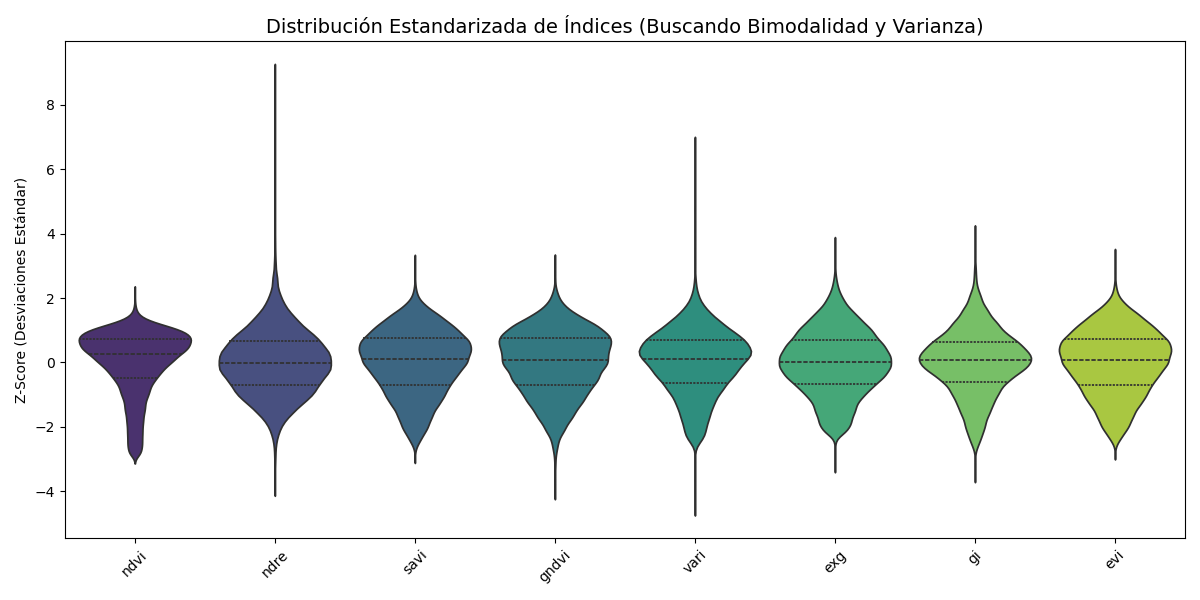

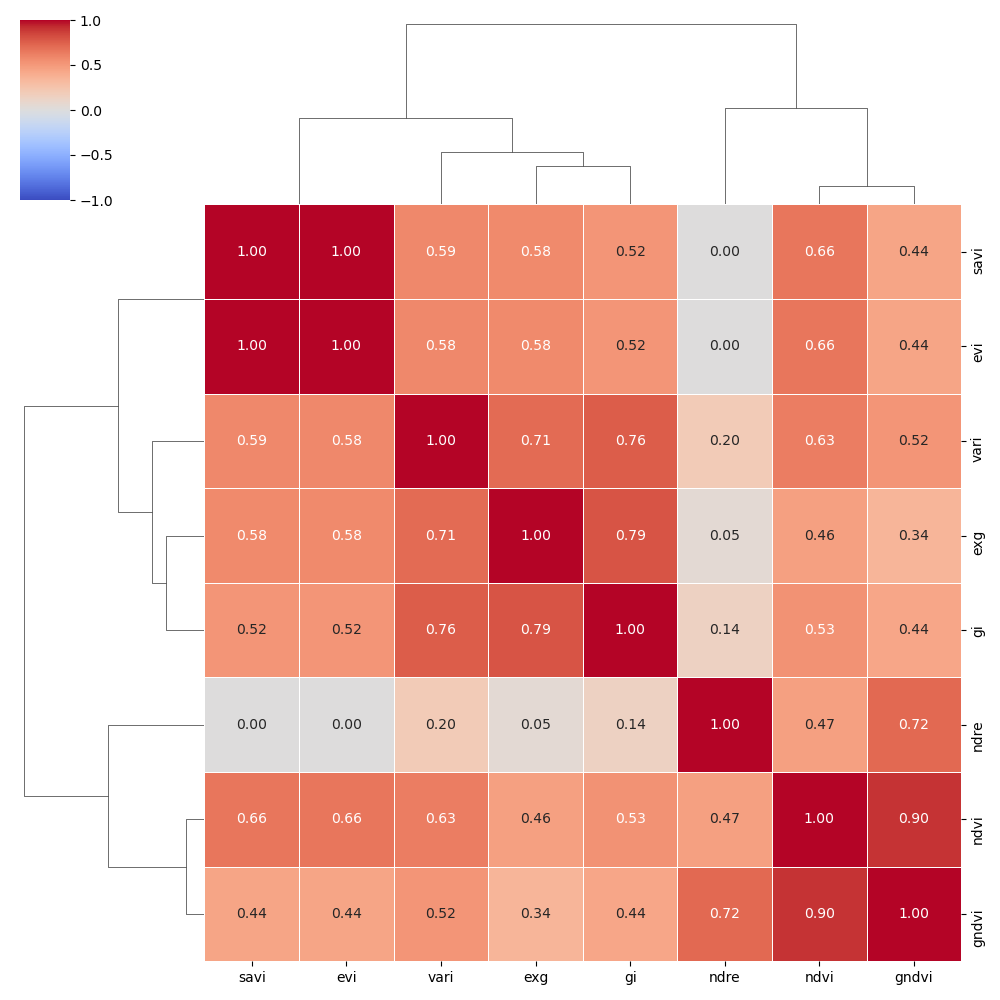

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# Asegurarnos de usar el DataFrame completo
df = df_features 

# 1. Aislamos solo las columnas de los índices vegetativos
indices_cols = ['ndvi', 'ndre', 'savi', 'gndvi', 'vari', 'exg', 'gi', 'evi']

# Tomamos una muestra aleatoria si el dataset es enorme para que grafique rápido (ej. 50k píxeles)
if len(df) > 50000:
    df_idx = df[indices_cols].sample(50000, random_state=42)
else:
    df_idx = df[indices_cols]

print("=== PASO 1: Estadísticas Descriptivas (Dispersión) ===")
# Calculamos el Coeficiente de Variación (CV = std / mean) 
# Mayor CV = Mayor capacidad teórica de discriminar diferencias
cv = (df_idx.std() / df_idx.mean()).abs().sort_values(ascending=False)
print("Coeficiente de Variación por índice:")
print(cv)
print("-" * 50)

# =========================================================
# PASO 2: Distribuciones (Violin Plots)
# =========================================================
# Estandarizamos los datos (Z-score) solo para el gráfico, así podemos compararlos en la misma escala
df_idx_std = (df_idx - df_idx.mean()) / df_idx.std()

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_idx_std, palette="viridis", inner="quartile")
plt.title("Distribución Estandarizada de Índices (Buscando Bimodalidad y Varianza)", fontsize=14)
plt.ylabel("Z-Score (Desviaciones Estándar)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================
# PASO 3: Correlación y Clústeres de Redundancia
# =========================================================
# Calculamos correlación de Spearman (mejor que Pearson para relaciones no lineales en vegetación)
corr = df_idx.corr(method='spearman')

# Preparamos la matriz para el Dendrograma (distancia = 1 - correlacion absoluta)
# Índices muy correlacionados tendrán distancia cercana a 0
dist_matrix = 1 - np.abs(corr)
linkage_matrix = hierarchy.linkage(squareform(dist_matrix), method='complete')

# Graficamos el Clustermap
g = sns.clustermap(corr, 
                   row_linkage=linkage_matrix, 
                   col_linkage=linkage_matrix, 
                   annot=True, 
                   fmt=".2f", 
                   cmap="coolwarm", 
                   vmin=-1, vmax=1, 
                   figsize=(10, 10),
                   linewidths=.5)

g.fig.suptitle('Clustermap de Correlación: Identificación de Redundancia', y=1.02, fontsize=14)
plt.show()

In [11]:
# Eliminamos SAVI por redundancia perfecta con EVI
df_features = df_features.drop(columns=['savi'])

print(f"Dataset optimizado. Columnas finales: {df_features.columns.tolist()}")

Dataset optimizado. Columnas finales: ['pos_x', 'pos_y', 'Verde', 'Rojo', 'Borde_Rojo', 'Infrarrojo_Cercano', 'Rojo_Vis', 'Verde_Vis', 'Azul_Vis', 'ndvi', 'ndre', 'gndvi', 'vari', 'exg', 'gi', 'evi', 'chm', 'ratio_ndvi_chm', 'rug_25cm', 'rug_55cm', 'rug_105cm']
